In [1]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
import pandas as pd
import ast
import time
from sklearn.model_selection import train_test_split

from mace import modules
from mace.data.atom_data_loader import AtomDataLoaderBuilder
from mace.testing import Tester, extract_latent_space
from mace.training import FreezeStrategy, NaiveStrategy, Trainer, initialise_autoencoder

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)

MAX_EPOCHS = 200
R_MAX = 5.0
BATCH_SIZE = 16
BASE_LR = 1.0e-3
TRANSFER_LR = 5.0e-4
DEVICE = torch.device("cpu")

# define wrapper classes
trainer = Trainer(
    max_epochs=MAX_EPOCHS, early_stopping=True, patience=15,
    restore_best=True, device=DEVICE, verbose=True,
)
data_builder = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
)
tester = Tester(device=DEVICE)
loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0, forces_weight=5.0, dipoles_weight=0.0,
    nacs_weight=0.0, socs_weight=0.0,
).to(DEVICE)


In [5]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / '../data'
SETTINGS_CSV = DATA_DIR / 'settings' / 'all_descriptor_selector_combinations.csv'
OUTPUT_DIR = ROOT_PATH / '../outputs'
RESULTS_CSV = OUTPUT_DIR / 'results' / 'all_descriptor_selector_combinations_results.csv'

SEED = 42
torch.manual_seed(SEED)

# Load base dataset
BASE_XYZ = DATA_DIR / 'A02_propene_grid_static_CASSCF.xyz'
BASE_N_GEOMETRIES = '3731' 
base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")

# Load transfer dataset
TRANSFER_XYZ = DATA_DIR / "A02_propene_grid_static_NEVPT2.xyz"
TRANSFER_N_GEOMETRIES = '3731'
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

# Load descriptor and selector pairs from CSV
settings = pd.read_csv(SETTINGS_CSV)


First structure info keys: ['REF_energy', 'REF_forces']
First structure arrays keys: ['numbers', 'positions']


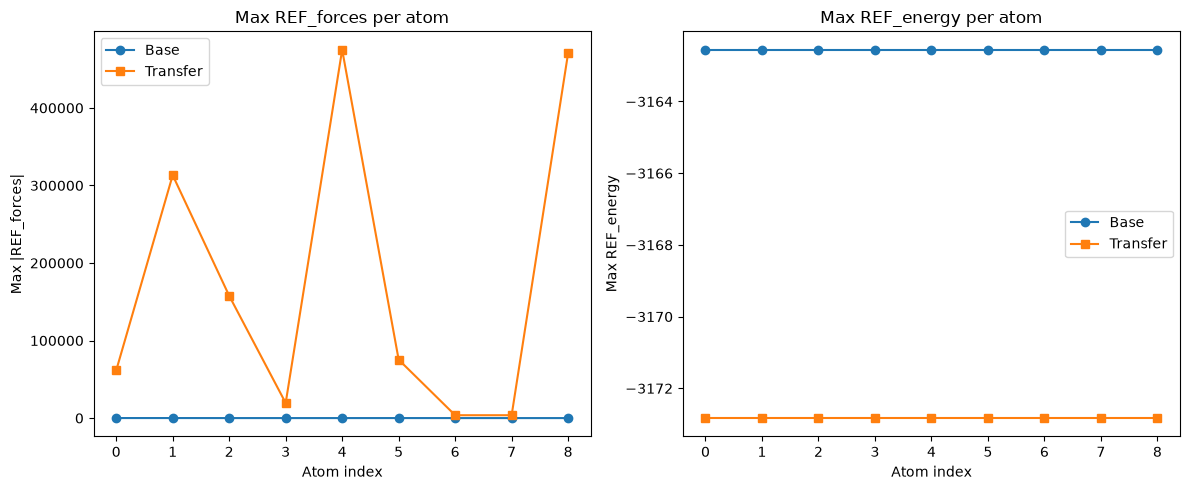

In [9]:
def _get_field(atoms, key):
    if key in atoms.info:
        value = atoms.info[key]
    elif key in atoms.arrays:
        value = atoms.arrays[key]
    else:
        available = sorted(list(atoms.info.keys()) + list(atoms.arrays.keys()))
        raise KeyError(f"{key} not found in atoms.info or atoms.arrays. Available keys: {available}")
    return np.asarray(value)


def max_force_per_atom(atoms_list):
    n_atoms = len(atoms_list[0])
    max_forces = np.zeros(n_atoms, dtype=float)
    for atoms in atoms_list:
        forces = _get_field(atoms, "REF_forces")
        if forces.ndim == 2 and forces.shape[1] == 3:
            force_norms = np.linalg.norm(forces, axis=1)
        elif forces.ndim == 3 and forces.shape[1:] == (3, 3):
            force_norms = np.max(np.linalg.norm(forces, axis=-1), axis=1)
        else:
            raise ValueError(f"Unexpected REF_forces shape: {forces.shape}")
        max_forces = np.maximum(max_forces, force_norms)
    return max_forces


def max_energy_per_atom(atoms_list):
    energies = []
    for atoms in atoms_list:
        energy = _get_field(atoms, "REF_energy")
        if energy.size == 0:
            raise ValueError("REF_energy is empty")
        energies.append(float(np.max(energy.reshape(-1))))
    max_e = np.max(energies)
    return np.full(len(atoms_list[0]), max_e)


# Debug: print the available metadata keys on the first structure.
if len(base_atoms_list) > 0:
    first_atoms = base_atoms_list[0]
    print("First structure info keys:", sorted(first_atoms.info.keys()))
    print("First structure arrays keys:", sorted(first_atoms.arrays.keys()))

base_max_forces = max_force_per_atom(base_atoms_list)
transfer_max_forces = max_force_per_atom(transfer_atoms_list)

base_max_energy = max_energy_per_atom(base_atoms_list)
transfer_max_energy = max_energy_per_atom(transfer_atoms_list)

base_indices = np.arange(len(base_max_forces))
transfer_indices = np.arange(len(transfer_max_forces))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(base_indices, base_max_forces, marker="o", label="Base")
plt.plot(transfer_indices, transfer_max_forces, marker="s", label="Transfer")
plt.xlabel("Atom index")
plt.ylabel("Max |REF_forces|")
plt.title("Max REF_forces per atom")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(base_indices, base_max_energy, marker="o", label="Base")
plt.plot(transfer_indices, transfer_max_energy, marker="s", label="Transfer")
plt.xlabel("Atom index")
plt.ylabel("Max REF_energy")
plt.title("Max REF_energy per atom")
plt.legend()

plt.tight_layout()
plt.show()
